Data: Open University Learning Analytics Dataset (OULAD)

https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad/data?select=studentAssessment.csv

In [2]:
import dowhy
from dowhy import CausalModel
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import graphviz as gr
from matplotlib import style
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
style.use("fivethirtyeight")


# Research Question: What is the causal effect of Highest Education on Final Exam Score?
* Treatment ($T$): Highest Education
  * $T = 1$: Highest Education Level of 'A Level or Equivalent' or 'Post Graduate Qualification'
  * $T = 0$: Highest Education Level of 'HE Qualification', 'Lowever than A Level' or 'No Formal quals'
* Mediator ($M$): Weighted Average TMA/CMA Score
* Confounder ($Z$): IMD Band
* Control ($x_s$): Number of Clicks, Number of TMA and CMA Quizes, Age Band

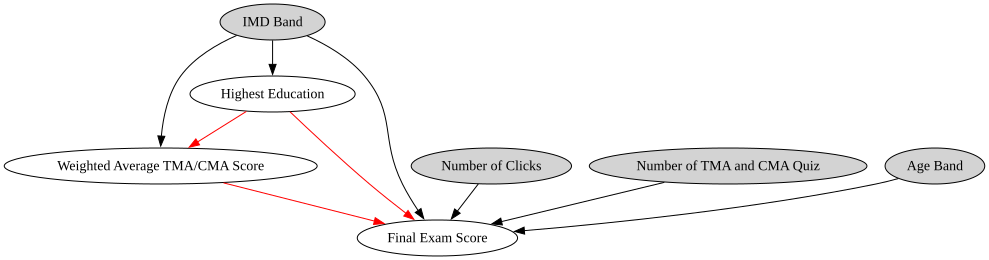

In [3]:
g = gr.Digraph()

g.edge('IMD Band', 'Highest Education')
g.edge('IMD Band', 'Weighted Average TMA/CMA Score')

# g.edge('Region', 'Highest Education')
# g.edge('Region', 'Weighted Average TMA/CMA Score')


g.edge('Highest Education', 'Weighted Average TMA/CMA Score', color ='red')
g.edge('Highest Education', 'Final Exam Score', color ='red')

g.edge('IMD Band', 'Final Exam Score')
# g.edge('Region', 'Final Exam Score')
g.edge('Weighted Average TMA/CMA Score', 'Final Exam Score', color ='red')

g.edge('Number of Clicks', 'Final Exam Score')
g.edge('Number of TMA and CMA Quiz', 'Final Exam Score')
g.edge('Age Band', 'Final Exam Score')
# g.edge('Different course', 'Final Score')

g.node('IMD Band', fillcolor  = 'lightgray', style = 'filled')
g.node('Number of Clicks', fillcolor  = 'lightgray', style = 'filled')
g.node('Number of TMA and CMA Quiz', fillcolor  = 'lightgray', style = 'filled')
g.node('Age Band', fillcolor  = 'lightgray', style = 'filled')
g

In [4]:
courses = pd.read_csv('Data/courses.csv')
assessments = pd.read_csv('Data/assessments.csv')
stu_assess = pd.read_csv('Data/studentAssessment.csv')
regist = pd.read_csv('Data/studentRegistration.csv')
vle = pd.read_csv('Data/studentVle.csv')
stu_info = pd.read_csv('Data/studentInfo.csv')

print(courses.head())
print(assessments.head())
print(stu_assess.head())
print(regist.head())
print(vle.head())
print(stu_info.head())

  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22  

In [5]:
# only keep students that did not drop out 
undrop_stu = regist[regist['date_unregistration'].isnull()]

# find the total click of the course materials at the student, and course level
undrop_vle = undrop_stu.merge(vle, how = 'left', on = ['id_student', 'code_module', 'code_presentation'])
crs_lvl_vle = undrop_vle.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].sum().reset_index(name ='tot_click')

# total course data
undrop_stu_score = undrop_stu.merge(stu_assess[stu_assess['is_banked'] == 0], how = 'left', on = ['id_student'])
crs_score = undrop_stu_score.merge(assessments, on = ['id_assessment','code_module', 'code_presentation'])

# tma_cma course_data summarized at the student-course level
tma_cma_crs_score = crs_score[crs_score['assessment_type'].isin(['TMA', 'CMA'])].copy()

tma_cma_crs_score['weighted_score'] = tma_cma_crs_score['weight']*0.01 * tma_cma_crs_score['score']
tma_cma_crs_lvl = tma_cma_crs_score.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    tot_quiz_weight = ('weight', 'sum'),
    quiz_weighted_avg_score = ('weighted_score', 'sum'),
    cnt_quiz = ('id_assessment','count')
).reset_index()
tma_cma_crs_lvl = tma_cma_crs_lvl[tma_cma_crs_lvl['tot_quiz_weight']== 100]


# final exam course_data summarized at the student-course level
exam_score = crs_score[crs_score['assessment_type']=='Exam'].copy()[['id_student', 'code_module', 'code_presentation', 'score']].rename(columns = {'score': 'final_score'})
exam_score = exam_score[['id_student', 'code_module', 'code_presentation','final_score']]


# combine the final exam score and the quiz score
all_tests = tma_cma_crs_lvl.merge(exam_score, on = ['id_student', 'code_module', 'code_presentation'])
all_tests_vle = all_tests.merge(crs_lvl_vle, on = ['id_student', 'code_module', 'code_presentation'])
print(all_tests_vle.head())


# add student info 
final_data = all_tests_vle.merge(stu_info, how = 'left', on = ['id_student', 'code_module', 'code_presentation'])
final_data = final_data.dropna()
print(final_data.head())
print(len(final_data))

   id_student code_module code_presentation  tot_quiz_weight  \
0       23698         CCC             2014J            100.0   
1       24213         DDD             2014B            100.0   
2       27116         CCC             2014J            100.0   
3       28046         DDD             2013J            100.0   
4       29411         DDD             2013J            100.0   

   quiz_weighted_avg_score  cnt_quiz  final_score  tot_click  
0                    69.97         8         80.0      910.0  
1                    78.40         6         58.0     1992.0  
2                    92.02         8         96.0     1847.0  
3                    49.90         6         40.0      661.0  
4                    75.65         6         62.0      841.0  
   id_student code_module code_presentation  tot_quiz_weight  \
0       23698         CCC             2014J            100.0   
1       24213         DDD             2014B            100.0   
2       27116         CCC             2014J  

In [6]:
# imd band
final_data['age_band_low'] = final_data['age_band'].str[:2].replace('0-', '0')
final_data['age_band_low'] = pd.to_numeric(final_data['age_band_low'])
print(final_data[['age_band','age_band_low']].drop_duplicates())

# age band 
final_data['imd_band_low'] = final_data['imd_band'].str[:2].replace('0-', '0')
final_data['imd_band_low'] = pd.to_numeric(final_data['imd_band_low'])

# create dummy variable
# final_data['highest_education_numeric'] = final_data['highest_education'].astype('category').cat.codes


# print(final_data[['age_band']].drop_duplicates())
# print(final_data[['highest_education','highest_education_numeric']].drop_duplicates() )

   age_band  age_band_low
0      0-35             0
3     35-55            35
10     55<=            55


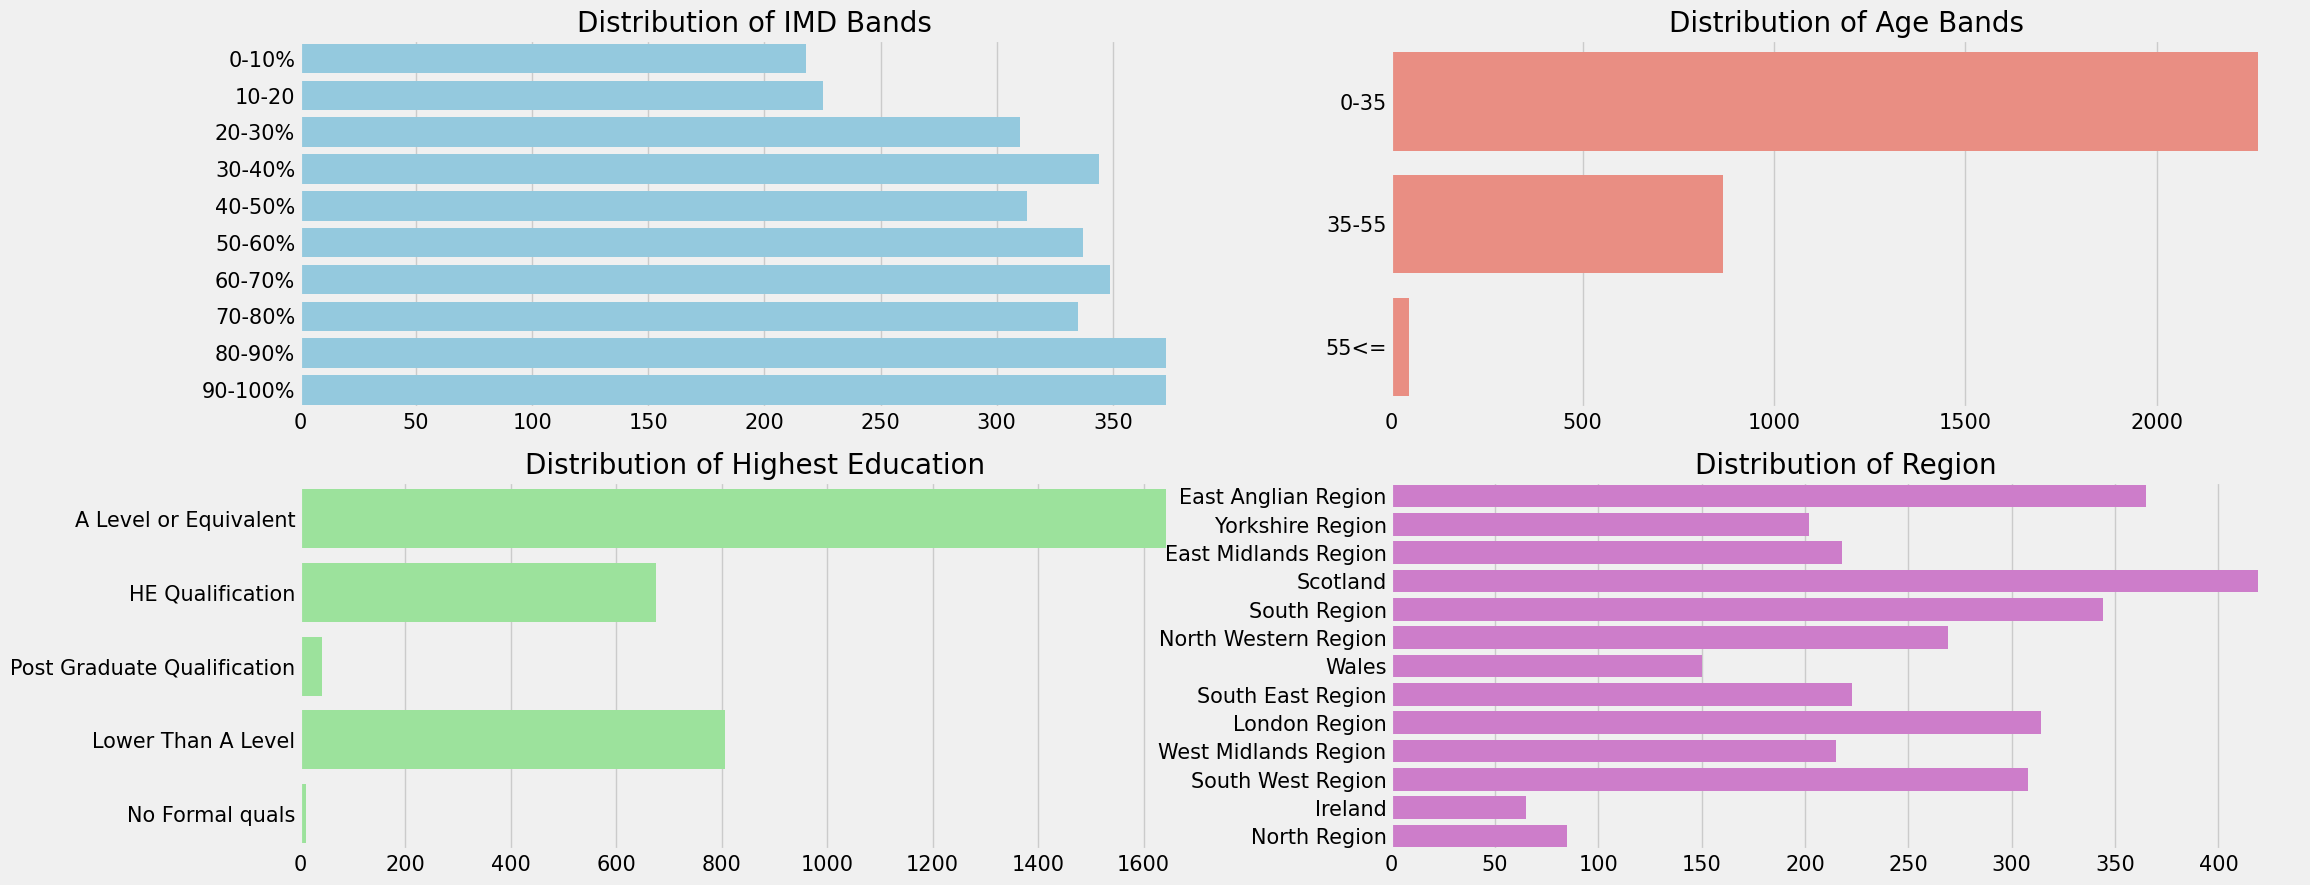

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(23, 10))

# IMD band plot 
imd_band_order = final_data.sort_values('imd_band_low')['imd_band'].unique()
sns.countplot(data = final_data, y='imd_band', ax = axes[0][0],color='skyblue', order = imd_band_order)

axes[0][0].set_title('Distribution of IMD Bands', fontsize=20)
axes[0][0].set_xlabel("")
axes[0][0].set_ylabel("")
# axes[0][0].set_ylabel('IMD Band', fontsize=15)
axes[0][0].tick_params(axis='both', labelsize=15)

# Age Band
age_band_order = final_data.sort_values('age_band_low')['age_band'].unique()
sns.countplot(data = final_data, y='age_band', ax = axes[0][1],color='salmon', order = age_band_order)

axes[0][1].set_title('Distribution of Age Bands', fontsize=20)
axes[0][1].set_xlabel("")
axes[0][1].set_ylabel("")
# axes[0][1].set_ylabel('Age Band', fontsize=15)
axes[0][1].tick_params(axis='both', labelsize=15)

# Highest Education

sns.countplot(data = final_data, y='highest_education', ax = axes[1][0],color='lightgreen')

axes[1][0].set_title('Distribution of Highest Education', fontsize=20)
axes[1][0].set_xlabel("")
axes[1][0].set_ylabel("")
# axes[1][0].set_ylabel('Highest Education', fontsize=15)
axes[1][0].tick_params(axis='both', labelsize=15)

# Region 
sns.countplot(data = final_data, y='region', ax = axes[1][1],color='orchid')

axes[1][1].set_title('Distribution of Region', fontsize=20)
axes[1][1].set_xlabel("")
axes[1][1].set_ylabel("")
# axes[1][1].set_ylabel('Region', fontsize=15)
axes[1][1].tick_params(axis='both', labelsize=15)

plt.show()

Comment: there is inequivalent distribution regarding age bands and educational level

In [8]:
# categorized Highest Education into two categories
final_data = final_data.assign(T = lambda df: (df['highest_education'].isin(['A Level or Equivalent', 'Post Graduate Qualification'])).astype(int))
final_data.groupby(['highest_education', 'T']).size().reset_index(name = 'count')

,highest_education,T,count
0,A Level or Equivalent,1,1643
1,HE Qualification,0,675
2,Lower Than A Level,0,806
3,No Formal quals,0,11
4,Post Graduate Qualification,1,42


In [9]:
print(final_data.head())
print(final_data.columns)

   id_student code_module code_presentation  tot_quiz_weight  \
0       23698         CCC             2014J            100.0   
1       24213         DDD             2014B            100.0   
2       27116         CCC             2014J            100.0   
3       28046         DDD             2013J            100.0   
4       29411         DDD             2013J            100.0   

   quiz_weighted_avg_score  cnt_quiz  final_score  tot_click gender  \
0                    69.97         8         80.0      910.0      F   
1                    78.40         6         58.0     1992.0      F   
2                    92.02         8         96.0     1847.0      M   
3                    49.90         6         40.0      661.0      F   
4                    75.65         6         62.0      841.0      M   

                 region      highest_education imd_band age_band  \
0   East Anglian Region  A Level or Equivalent   50-60%     0-35   
1   East Anglian Region  A Level or Equivalent   40-

# Frisch- Waugh-Lovell Theorem


In [15]:
# ordinary regression
y_on_t_x_model = smf.ols('final_score~ T+C(imd_band_low) + cnt_quiz + tot_click + C(age_band_low)', data = final_data).fit()
print(y_on_t_x_model.summary().tables[1])

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                64.5913      1.853     34.866      0.000      60.959      68.224
C(imd_band_low)[T.10]     1.6685      1.859      0.898      0.369      -1.976       5.313
C(imd_band_low)[T.20]     3.4515      1.729      1.996      0.046       0.061       6.842
C(imd_band_low)[T.30]     1.0931      1.695      0.645      0.519      -2.231       4.417
C(imd_band_low)[T.40]     1.7136      1.728      0.992      0.321      -1.675       5.102
C(imd_band_low)[T.50]     1.5198      1.701      0.893      0.372      -1.815       4.855
C(imd_band_low)[T.60]     1.7322      1.689      1.026      0.305      -1.579       5.044
C(imd_band_low)[T.70]     3.7989      1.705      2.229      0.026       0.457       7.141
C(imd_band_low)[T.80]     4.1600      1.670      2.491      0.013       0.885       7.435
C(imd_band

In [13]:
t_on_x_model = smf.ols('T~ C(imd_band_low) + cnt_quiz + tot_click + C(age_band_low)', data = final_data).fit()
print(t_on_x_model.summary().tables[1])
final_data['res_t'] = t_on_x_model.resid
y_on_x_model = smf.ols('final_score~ C(imd_band_low) + cnt_quiz + tot_click + C(age_band_low)', data = final_data).fit()
print(y_on_x_model.summary().tables[1])
final_data['res_y'] = y_on_x_model.resid
fwl_model = smf.ols('res_y ~ res_t - 1', data = final_data).fit()
print(fwl_model.summary().tables[1])

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.5998      0.045     13.185      0.000       0.511       0.689
C(imd_band_low)[T.10]     0.0202      0.047      0.432      0.666      -0.072       0.112
C(imd_band_low)[T.20]    -0.0620      0.044     -1.423      0.155      -0.148       0.023
C(imd_band_low)[T.30]     0.0167      0.043      0.392      0.695      -0.067       0.101
C(imd_band_low)[T.40]    -0.0144      0.044     -0.330      0.741      -0.100       0.071
C(imd_band_low)[T.50]     0.0153      0.043      0.356      0.722      -0.069       0.099
C(imd_band_low)[T.60]    -0.0159      0.043     -0.373      0.709      -0.099       0.068
C(imd_band_low)[T.70]    -0.0193      0.043     -0.449      0.653      -0.104       0.065
C(imd_band_low)[T.80]    -0.0153      0.042     -0.362      0.717      -0.098       0.067
C(imd_band

In [12]:
# stu_info.groupby(['age_band'])['id_student'].count().reset_index(name = 'cnt_stu')
# young_stu = stu_info[(stu_info['age_band'] =='0-35') & (stu_info['highest_education'] =='A Level or Equivalent')]

# print(young_stu.groupby('num_of_prev_attempts').count())

https://en.wikipedia.org/wiki/Frisch%E2%80%93Waugh%E2%80%93Lovell_theorem
